In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [ ]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        fx = vx
        fy = vy

        # dt(x) = active * vx  #Change position acording to constant speed afected by forces
        # dt(y) = active * vy  
        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false
            x = 0
            y = 0
            vx = 0.0
            vy = 0.0

        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

        end

        # #Periodic boundry
        # xmin, xmax = simBox[1,1]*0.9, simBox[1,2]*0.9
        # ymin, ymax = simBox[2,1]*0.9, simBox[2,2]*0.9
        # # X direction
        # if x < xmin
        #     x += (xmax - xmin)
        # elseif x > xmax
        #     x -= (xmax - xmin)
        # end

        # # Y direction
        # if y < ymin
        #     y += (ymax - ymin)
        # elseif y > ymax
        #     y -= (ymax - ymin)
        # end

        #Previous boundry conditions
        # if x < simBox[1,1]*0.9
        #     x = simBox[1,1]*0.9
        #     theta = pi - theta   
        # elseif x > simBox[1,2]*0.9
        #     x = simBox[1,2]*0.9
        #     theta = pi - theta
        # end
        # if y < simBox[2,1]*0.9
        #     y = simBox[2,1]*0.9
        #     theta = -theta/2
        # elseif y > simBox[2,2]*0.9
        #     y = simBox[2,2]*0.9
        #     theta = -theta/2
        # end

    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

In [2]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

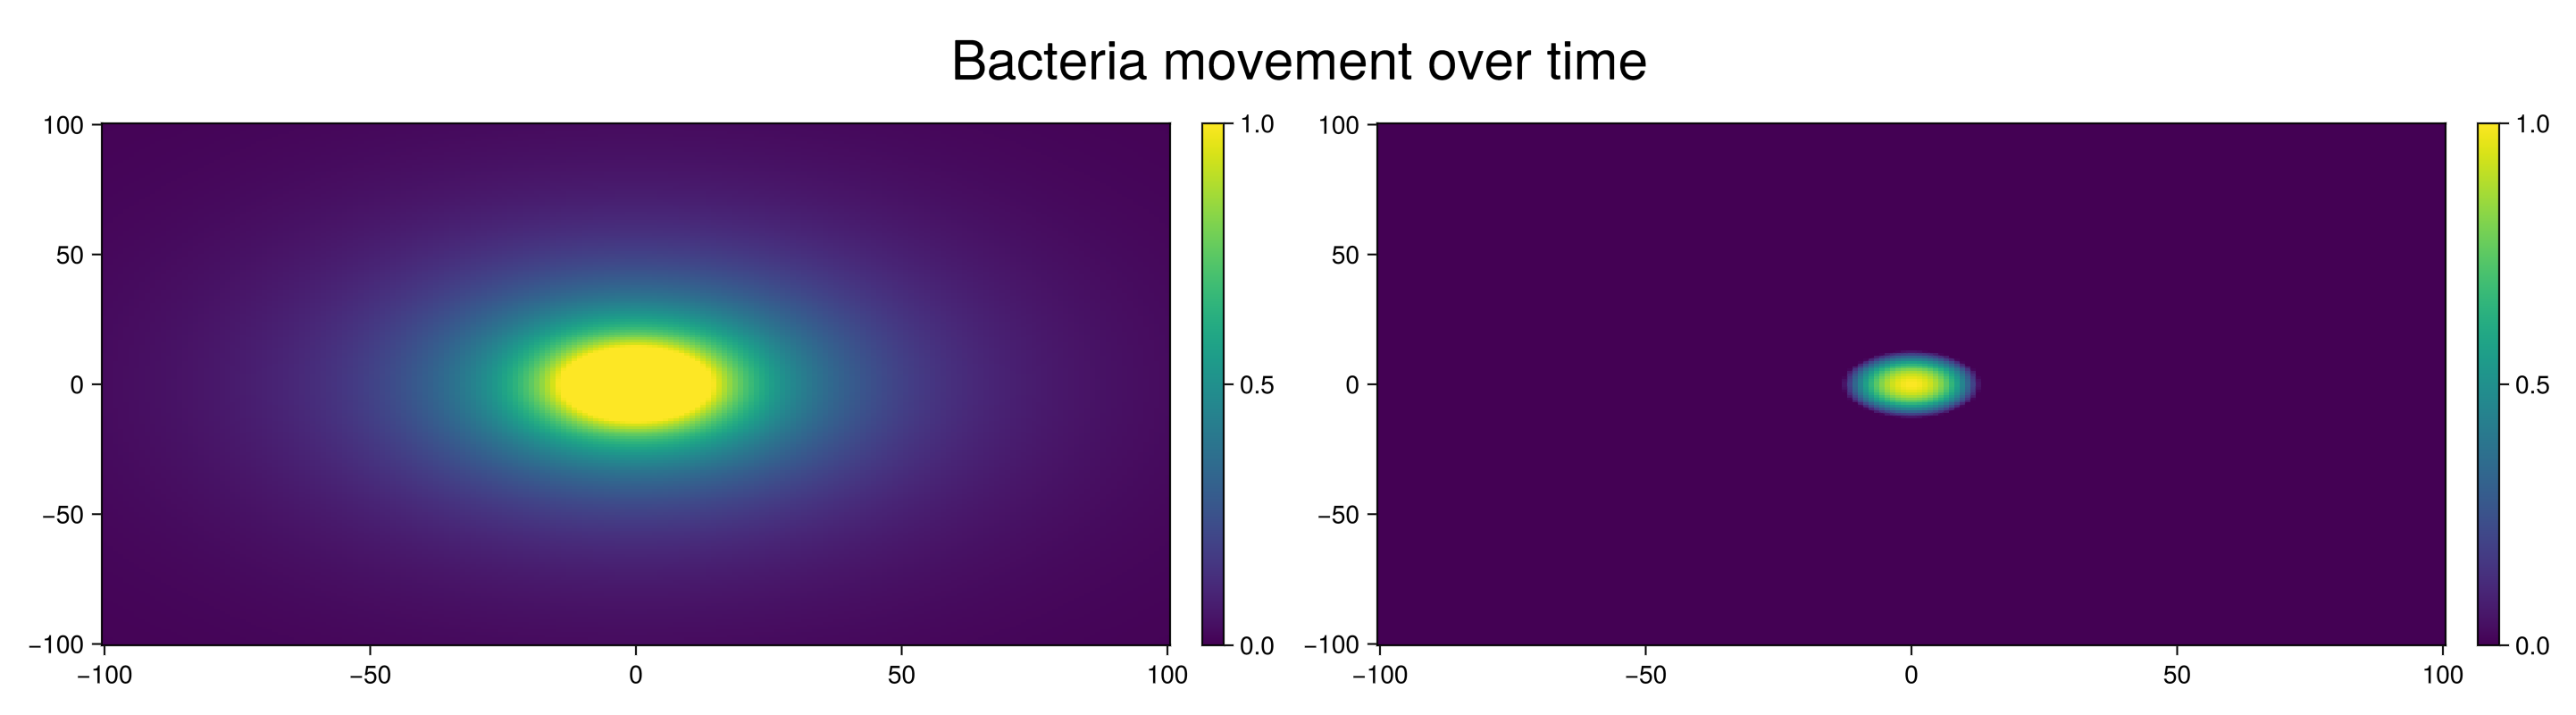

GLMakie.Screen(...)

In [61]:
fig2 = Figure(size=(2100,400))

ax = Axis(fig2[1,1])
ax_2 = Axis(fig2[1,3])
xs, ys = 0.0, 0.0


len = Int(100 + 100)
# x_grid = range(com.simBox[1], com.simBox[3], length=len)
# y_grid = range(com.simBox[2], com.simBox[4], length=len)
x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(10 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis, colorrange=(0,1))
Colorbar(fig2[1,2],hm)

A = 1.0
mm_grid_2 = @. A - 0.006 * ((X - xs)^2 + (Y - ys)^2)

hm_2 = heatmap!(ax_2, x_grid, y_grid, mm_grid_2, colormap=:viridis, colorrange=(0,1))
Colorbar(fig2[1,4],hm_2)


# sideinfo = Label(fig2[2, 1:5], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
supertitle  = Label(fig2[0, :], "Bacteria movement over time", fontsize = 30)

display(fig2)

In [45]:
using Statistics

# Original field
mm_bessel = @. besselk(0, r / λ)

# Normalize both to compare shape only
mm_bessel ./= maximum(mm_bessel)

# Try different α values
alphas = range(0.001, 0.1, length=100)

best_α = nothing
best_err = Inf

for α in alphas
    mm_parab = @. 1.0 - α * r^2
    mm_parab = max.(mm_parab, 0)   # avoid negative tails
    mm_parab ./= maximum(mm_parab)

    err = mean((mm_parab .- mm_bessel).^2)

    if err < best_err
        best_err = err
        best_α = α
    end
end

println(best_α)

0.006
